# Neural Network from Scratch (Linear Algebra)

Neural networks learn by making predictions, measuring their error with a loss function, and using **backpropagation** to compute how much each weight contributed to that error. These gradients are then used by **gradient descent** to iteratively nudge weights in the direction that reduces loss. This is repeated over many passes until the network converges.

In this notebook we construct a 3-layer neural network using purely linear algebra and matrix operations via NumPy. We apply it to a binary classification problem: predicting heart disease risk from clinical features.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1 + np.exp(-x)) #Sigmoid Activation function for Neurons

def dSigdIn(x):
    return sigmoid(x)*(1-sigmoid(x))

def loss(y, x): #(target, input)
    return 0.5*((y - x)**2)

def dLdOut(y, x): #(target, input)
    return -(y-x)


## 1. Data Preprocessing

Import data and reshape to appropriate size before partitioning between test and training data.

In [2]:
import pandas as pd

df = pd.read_csv('heart-disease.csv')
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)

n_samples = X.shape[0]
print(n_samples)

rng = np.random.default_rng(seed=42)
indices = rng.permutation(n_samples)
X = X[indices]
y = y[indices]

# Normalise features to zero mean and unit variance
mu = X.mean(axis=0)
std = X.std(axis=0)
X = (X - mu) / std

kf = 5
foldSize = n_samples // kf
print(foldSize)

303
60


## 2. Neural Network Initialisation and training per fold

As previously described, for each fold we construct a 3 layered neural network with 5 neurons in each hidden layer. We then train the model initially with stochastic gradient descent.

In [3]:

netDims = [5, 5, 1] # Neural net Architecture, 2 hidden 5 neuron layers with final output neuron

batchSize = 50 # Set size of batch used in backpropagation averaging and subsequnt gradient descent
batches = int(np.ceil((n_samples - foldSize) / batchSize))

epochs = 10000 # Contols number of times we iterate threough comnplete data set before halting training
alpha = 0.01 # Learning rate - changes magnitude of gradient descent jump

LossesTrain, LossesVal = np.zeros((kf, epochs)), np.zeros((kf, epochs))

TP_total, TN_total, FP_total, FN_total = 0, 0, 0, 0

total_outputs = []
total_labels = []

for i in range(kf):
    # Partitian the X and y matrices according to fold
    
    start = i*foldSize
    end = (i+1)*foldSize
    
    X_test = X[start:end, :]
    y_test = y[start:end, :]

    X_train = np.vstack((X[:start, :], X[end:, :]))
    y_train = np.vstack((y[:start, :], y[end:, :]))

    # Initialise weight matrices with random weights, in accordance with Xavier initialisation
    w1 = rng.standard_normal((X_train.shape[1], netDims[0])) * (1/np.sqrt(X_train.shape[1]))
    w2 = rng.standard_normal((netDims[0], netDims[1])) * (1/np.sqrt(netDims[0]))
    w3 = rng.standard_normal((netDims[1], netDims[2])) * (1/np.sqrt(netDims[1]))

    b1 = np.zeros((1, netDims[0]))
    b2 = np.zeros((1, netDims[1]))
    b3 = np.zeros((1, netDims[2])) # bias initialised as 0 in accordance to Xavier initialisation principals

    # Split test set into batches and iterate through batch before making weight adjustments based on average backpropagted error
    for j in range(epochs):
        #Shuffle training samples
        indices = rng.permutation(X_train.shape[0])
        X_train = X_train[indices]
        y_train = y_train[indices]

        for k in range(batches): # Iterate across all batches
            startB = k*batchSize
            endB = (k+1)*batchSize
            batch_X = X_train[startB:endB, :]
            batch_y = y_train[startB:endB, :]

            actual_batch_size = batch_X.shape[0]

            # forward propagate input vectors through network to get output and calculate Loss across all sample vectors
            in1 = batch_X @ w1 + b1
            out1 = sigmoid(in1)
            in2 = out1 @ w2 + b2
            out2 = sigmoid(in2)
            in3 = out2 @ w3 + b3
            out3 = sigmoid(in3)

            L = loss(batch_y, out3)

            # Calculate backpropagated error - full form
            # dLdw1 = 1/batchSize * (batch_X.T @ ((((( dLdOut(batch_y, out3) * dSigdIn(in3)) @ w3.T) * dSigdIn(in2)) @ w2.T) * dSigdIn(in1)))
            # dLdw2 = 1/batchSize * (out1.T @ ((( dLdOut(batch_y, out3) * dSigdIn(in3)) @ w3.T) * dSigdIn(in2)))
            # dLdw3 = 1/batchSize * (out2.T @ (dLdOut(batch_y, out3) * dSigdIn(in3))) 

            # dLdb1 = 1/batchSize * (np.ones((1, batchSize)) @ ((((( dLdOut(batch_y, out3) * dSigdIn(in3)) @ w3.T) * dSigdIn(in2)) @ w2.T) * dSigdIn(in1)))
            # dLdb2 = 1/batchSize * (np.ones((1, out1.shape[0])) @ ((( dLdOut(batch_y, out3) * dSigdIn(in3)) @ w3.T) * dSigdIn(in2)))
            # dLdb3 = 1/batchSize * (np.ones((1, out2.shape[0])) @ (dLdOut(batch_y, out3) * dSigdIn(in3)))

            # Calculated backpropagated error improved - modular form
            dLdin3 = dLdOut(batch_y, out3) * dSigdIn(in3)
            dLdin2 = (dLdin3 @ w3.T) * dSigdIn(in2)
            dLdin1 = (dLdin2 @ w2.T) * dSigdIn(in1)

            dLdw1 = 1/batchSize * (batch_X.T @ (dLdin1))
            dLdw2 = 1/batchSize * (out1.T @ (dLdin2))
            dLdw3 = 1/batchSize * (out2.T @ (dLdin3))

            dLdb1 = 1/batchSize * (np.ones((1, actual_batch_size)) @ (dLdin1))
            dLdb2 = 1/batchSize * (np.ones((1, actual_batch_size)) @ (dLdin2))
            dLdb3 = 1/batchSize * (np.ones((1, actual_batch_size)) @ (dLdin3))

                      
            # Update weights based on gradient descent values
            w1 = w1 - alpha*dLdw1
            w2 = w2 - alpha*dLdw2
            w3 = w3 - alpha*dLdw3

            b1 = b1 - alpha*dLdb1
            b2 = b2 - alpha*dLdb2
            b3 = b3 - alpha*dLdb3

        # After all training elements have been iterated through (batch loop complete), classify all elements of test set and record average Loss
        in1 = X_train @ w1 + b1
        out1 = sigmoid(in1)
        in2 = out1 @ w2 + b2
        out2 = sigmoid(in2)
        in3 = out2 @ w3 + b3
        out3 = sigmoid(in3)
        Loss = loss(y_train, out3)
        LossesTrain[i,j] = np.mean(Loss)

        # Now forward propagate tesdt set to get current mean loss across samples
        in1 = X_test @ w1 + b1
        out1 = sigmoid(in1)
        in2 = out1 @ w2 + b2
        out2 = sigmoid(in2)
        in3 = out2 @ w3 + b3
        out3 = sigmoid(in3)
        Loss = loss(y_test, out3)
        LossesVal[i,j] = np.mean(Loss)
        

    # At the conclusion of all epochs, again forward propagte all test vectors but this time classify to 1 or 0 and then measure update confusion matrix
    in1 = X_test @ w1 + b1
    out1 = sigmoid(in1)
    in2 = out1 @ w2 + b2
    out2 = sigmoid(in2)
    in3 = out2 @ w3 + b3
    out3 = sigmoid(in3)

    
    print("Out shape: ", out3.shape)
    total_outputs.append(out3)
    print("y shape: ", y_test.shape)
    total_labels.append(y_test)

    y_predicted = out3 > 0.5

    TP = np.sum((y_predicted == 1) & (y_test == 1))
    TN = np.sum((y_predicted == 0) & (y_test == 0))
    FP = np.sum((y_predicted == 1) & (y_test == 0))
    FN = np.sum((y_predicted == 0) & (y_test == 1))

    TP_total += TP
    TN_total += TN
    FP_total += FP
    FN_total += FN




Out shape:  (60, 1)
y shape:  (60, 1)
Out shape:  (60, 1)
y shape:  (60, 1)
Out shape:  (60, 1)
y shape:  (60, 1)
Out shape:  (60, 1)
y shape:  (60, 1)
Out shape:  (60, 1)
y shape:  (60, 1)


## 3. Model Evaluation

We evaliate model performance considering loss training curves as well as a number of KPI such as Recall, Prescision, Specificity, F1 score and an ROC curve with AUC calculation.

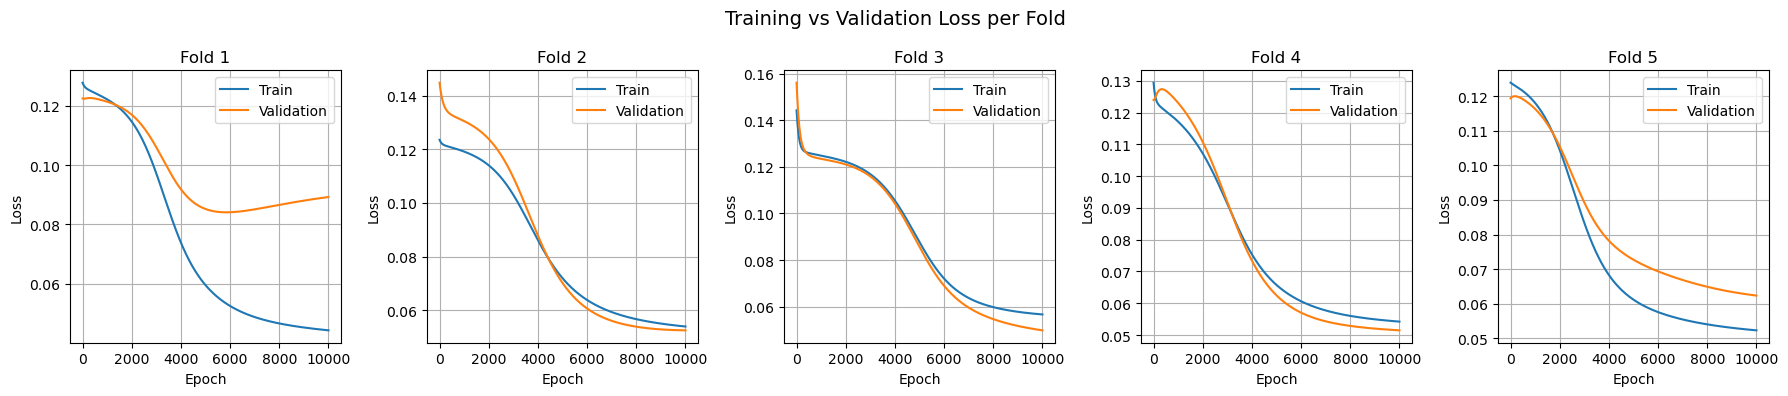

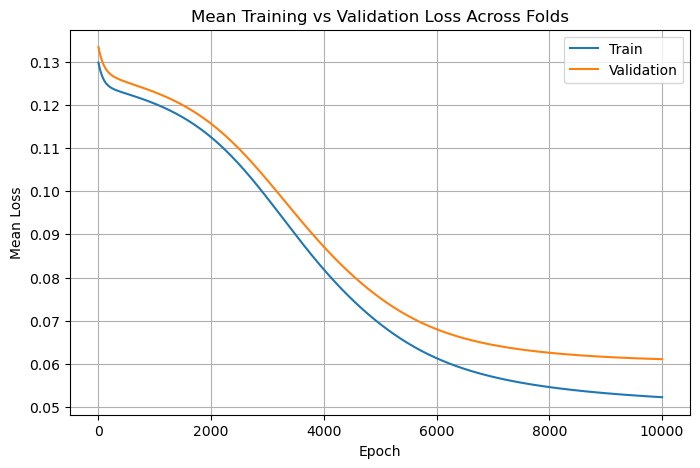

Recall:      0.8827160493827161
Precision:   0.8218390804597702
Specificity: 0.7753623188405797
F1 Score:    0.8511904761904763
Accuracy:    0.8333333333333334


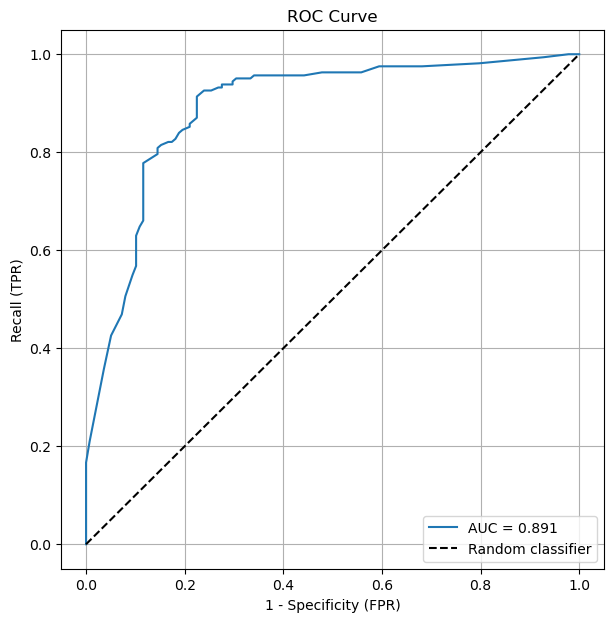

In [4]:
epoch_plot = np.arange(1, epochs + 1)
TrainLoss_plot = np.mean(LossesTrain, axis=0)
ValLoss_plot = np.mean(LossesVal, axis=0)

# Per fold plots
fig, axes = plt.subplots(1, kf, figsize=(18, 4))
for i in range(kf):
    axes[i].plot(epoch_plot, LossesTrain[i, :], label="Train")
    axes[i].plot(epoch_plot, LossesVal[i, :], label="Validation")
    axes[i].set_title(f"Fold {i+1}")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)
plt.suptitle("Training vs Validation Loss per Fold", fontsize=14)
plt.tight_layout()
plt.show()

# Mean loss plot
plt.figure(figsize=(8, 5))
plt.plot(epoch_plot, TrainLoss_plot, label="Train")
plt.plot(epoch_plot, ValLoss_plot, label="Validation")
plt.title("Mean Training vs Validation Loss Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.legend()
plt.grid(True)
plt.show()


# Confusion Matrix Perormance Indicators
recall = TP_total/(TP_total + FN_total)
precision = TP_total/(TP_total + FP_total)
specificity = TN_total/(TN_total + FP_total)
f1 = 2 * (recall * precision)/(recall + precision)

print("Recall:     ", recall)
print("Precision:  ", precision)
print("Specificity:", specificity)
print("F1 Score:   ", f1)
print("Accuracy:   ", (TP_total + TN_total) / (TP_total + TN_total + FP_total + FN_total))


### ROC ###

ROC_recall = []
ROC_invSpecificity = []

total_outputs_stack = np.vstack(total_outputs)
total_labels_stack = np.vstack(total_labels)

# Iterate over different clasification levesl to generate ROC curve
for c in np.linspace(0, 1, 100):
    total_predictions = (total_outputs_stack > c).astype(int)
    TP = np.sum((total_predictions == 1) & (total_labels_stack == 1))
    TN = np.sum((total_predictions == 0) & (total_labels_stack == 0))
    FP = np.sum((total_predictions == 1) & (total_labels_stack == 0))
    FN = np.sum((total_predictions == 0) & (total_labels_stack == 1))
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    ROC_recall.append(recall)
    ROC_invSpecificity.append(1 - specificity)

# AUC via trapezoidal rule
auc = np.abs(np.trapz(ROC_recall, ROC_invSpecificity))

plt.figure(figsize=(7, 7))
plt.plot(ROC_invSpecificity, ROC_recall, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")
plt.xlabel("1 - Specificity (FPR)")
plt.ylabel("Recall (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
    